In [ ]:
import sympy as sp
import numpy as np


## Calculating $S(\rho, \gamma)$ as a function of entries of matrix $\rho$

In [ ]:
# make a 4x4 matrix rho with symbolic entries
rhos = [[sp.Symbol(f'rho_{i}_{j}') for j in range(1,5)] for i in range(1,5)]
rho = sp.Matrix(rhos)  
gamma= sp.symbols('gamma')

$$
U_1(\gamma) = 
\begin{pmatrix}
\cos\gamma  & 0 & 0 & -\sin\gamma\\
0 & 1 & 0 & 0\\
0 & 0 & 1 & 0\\
\sin\gamma & 0 & 0 & \cos\gamma
\end{pmatrix}, \ 
U_2(\gamma) =
\begin{pmatrix}
1 & 0 & 0 & 0\\
0 & \cos\gamma & -\sin\gamma & 0\\
0 & \sin\gamma & \cos\gamma & 0\\
0 & 0 & 0 & 1
\end{pmatrix},
$$

Let us take $\gamma \in [\pi/24, \pi/8]$ as a choice made by an adversary.


In [40]:
# do the calculations already done by Masoumeh to check
U1 =sp.Matrix([[sp.cos(gamma), 0, 0, -sp.sin(gamma)],
                [0, 1, 0, 0],
                [0, 0, 1, 0],
                [sp.sin(gamma), 0, 0, sp.cos(gamma)]])
U2 = sp.Matrix([[1, 0, 0, 0],
                [0, sp.cos(gamma), -sp.sin(gamma), 0],
                [0, sp.sin(gamma), sp.cos(gamma), 0],
                [0, 0, 0, 1]])


Phi = 1/sp.sqrt(2)   * sp.Matrix([[1], [0], [0], [1]])

s1 = sp.simplify(Phi.T * U1 * rho * U1.T * Phi)
s2 = sp.simplify(Phi.T * U2 * rho * U2.T * Phi) 
print ('s1 = ', s1)
print ('s2 = ', s2)

s_gamma_rho = sp.Rational(1, 2) * sp.simplify(s1[0] + s2[0])
print('S(\\gamma, \\rho) = ', s_gamma_rho)


s1 =  Matrix([[rho_1_1*sin(2*gamma)/2 + rho_1_1/2 + rho_1_4*cos(2*gamma)/2 + rho_4_1*cos(2*gamma)/2 - rho_4_4*sin(2*gamma)/2 + rho_4_4/2]])
s2 =  Matrix([[rho_1_1/2 + rho_1_4/2 + rho_4_1/2 + rho_4_4/2]])
S(\gamma, \rho) =  rho_1_1*sin(2*gamma)/4 + rho_1_1/2 + rho_1_4*cos(2*gamma)/4 + rho_1_4/4 + rho_4_1*cos(2*gamma)/4 + rho_4_1/4 - rho_4_4*sin(2*gamma)/4 + rho_4_4/2


In [41]:
from IPython.display import display, Math

# S(gamma, rho) in LaTeX
display(Math(r'S(\gamma, \rho) = ' + sp.latex(s_gamma_rho)))

# S(gamma, rho) as a polynomial in rho_1_1 ... rho_4_4
rho_syms = rhos[0] + rhos[1] + rhos[2] + rhos[3]
s_poly = sp.poly(s_gamma_rho, gens=rho_syms)
print("As a polynomial in rho entries:")
for m, c in zip(s_poly.monoms(), s_poly.coeffs()):
    rho_term = ' * '.join(f'{str(rho_syms[i])}^{e}' if e > 1 else str(rho_syms[i])
                          for i, e in enumerate(m) if e > 0)
    print(f'  ({sp.simplify(c)}) * {rho_term}')


<IPython.core.display.Math object>

As a polynomial in rho entries:
  (sin(2*gamma)/4 + 1/2) * rho_1_1
  (cos(gamma)**2/2) * rho_1_4
  (cos(gamma)**2/2) * rho_4_1
  (1/2 - sin(2*gamma)/4) * rho_4_4


## Taylor approximation of $\sin(2\gamma)$ and $\cos(2\gamma)$.

Let us assume that $\gamma \in [\pi/24, \pi/8]$. Then $2 \gamma = \theta \in [\pi/12, \pi/4]$.

We can approximate $\sin(\theta) = \sin(\pi/6) + (\theta - \pi/6) \cos(\pi/6) - \frac{(\theta - \pi/6)^2}{2} \sin(\alpha)$ 
and $\cos(\theta) = \cos(\pi/6) - (\theta - \pi/6) \sin(\pi/6) - \frac{(\theta-\pi/6)^2}{2} \cos(\alpha)$

Here $\alpha \in [\pi/12,\pi/4]$ with the last term representing the Lagrange reminder.  We note that 
$\frac{(\theta - \pi/6)^2}{2} \sin(\alpha) \in [0, 0.5 * (\pi/12)^2 \sin(\pi/4)]$

Similarly $\frac{(\theta - \pi/6)^2}{2} \cos(\alpha) \in [0, 0.5*\pi^2/12 \cos(\pi/12)]$

In [35]:
# let's calculate the numerical values of the intervals for Lagrange remainder
print(0.5* np.pi**2/144 * np.sin(np.pi/4))
print(0.5* np.pi**2/144 * np.cos(np.pi/12))
# note that these bounds are inverted since there is a negative sign in the Lagrange remainder.

0.02423216735985722
0.03310175620232105


In [36]:
#estimate it empirically 
import numpy as np

def sin_approx(t):
    return 1/2 + (t - np.pi/6) * np.sqrt(3)/2
def cos_approx(t):
    return np.sqrt(3)/2 - (t - np.pi/6) * 1/2

def estimate_approx_error():
    pts = np.linspace(np.pi/12, np.pi/4, 1000)
    e_sin = np.sin(pts) - sin_approx(pts)
    e_cos = np.cos(pts) - cos_approx(pts)
    return np.min(e_sin), np.max(e_sin), np.min(e_cos), np.max(e_cos)

print(estimate_approx_error())

(np.float64(-0.019618139342729712), np.float64(-1.7166453036843166e-08), np.float64(-0.03099927139494496), np.float64(-2.9736168194460788e-08))


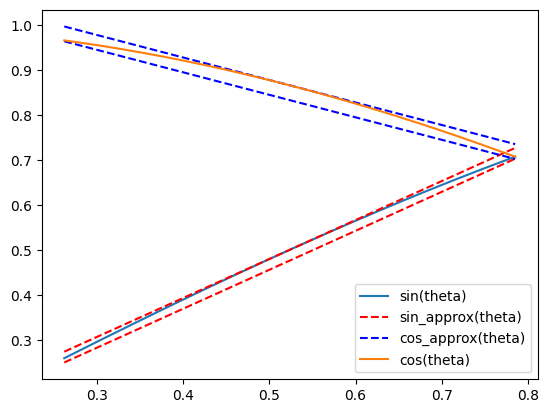

In [37]:
from matplotlib import pyplot as plt
# plot sin(theta) and cos(theta) for theta in [\pi/12,\pi/4]

import numpy as np
plt.plot([theta for theta in np.linspace(sp.pi/12, sp.pi/4, 1000)], [sp.sin(theta) for theta in np.linspace(sp.pi/12, sp.pi/4, 1000)], label='sin(theta)')
plt.plot([theta for theta in np.linspace(sp.pi/12, sp.pi/4, 1000)], [sin_approx(theta) for theta in np.linspace(sp.pi/12, sp.pi/4, 1000)], '--r', label='sin_approx(theta)')
plt.plot([theta for theta in np.linspace(sp.pi/12, sp.pi/4, 1000)], [cos_approx(theta) for theta in np.linspace(sp.pi/12, sp.pi/4, 1000)], '--b', label='cos_approx(theta)')
plt.plot([theta for theta in np.linspace(sp.pi/12, sp.pi/4, 1000)], [sin_approx(theta)-0.024 for theta in np.linspace(sp.pi/12, sp.pi/4, 1000)], '--r', label='')
plt.plot([theta for theta in np.linspace(sp.pi/12, sp.pi/4, 1000)], [cos_approx(theta)-0.033 for theta in np.linspace(sp.pi/12, sp.pi/4, 1000)], '--b', label='')
plt.plot([theta for theta in np.linspace(sp.pi/12, sp.pi/4, 1000)], [sp.cos(theta) for theta in np.linspace(sp.pi/12, sp.pi/4, 1000)], label='cos(theta)')
plt.legend()
plt.show()

## Substituting approximations for sine/cosine into $S(\gamma, \rho)$

We will substitute $\sin(\theta) \in a + b \theta + e_1$ wherein $a = \sin(\pi/6) - \pi/6 \cos(\pi/6)$, $b = \cos(\pi/6)$ and $e_1 \in [-0.024,0]$
Likewise
$\cos\theta \in c  + d \theta + e_2 $ wherein $c = \cos(\pi/6) + \pi/6 \sin(\pi/6), d = -\sin(\pi/6)$ and $e_2 \in [-0.033,0]$ 

In [42]:
t = sp.symbols('t')
err_s = sp.symbols('err_s')
err_c = sp.symbols('err_c')
sin_approx_expr = sp.Rational(1,2) + (t - sp.pi/6) * sp.sqrt(3)/2 + err_s
cos_approx_expr = sp.sqrt(3)/2 - (t - sp.pi/6) * sp.Rational(1,2) + err_c

# substiute sin_approx_eexpr for sin(theta) and cos_approx_expr for cos(theta) in s_theta_rho   
s_theta_rho_approx = sp.poly(s_gamma_rho.subs({sp.sin(2*gamma): sin_approx_expr, sp.cos(2*gamma): cos_approx_expr}), gens=[t, err_s, err_c])
print(s_theta_rho_approx)

Poly((sqrt(3)*rho_1_1/8 - rho_1_4/8 - rho_4_1/8 - sqrt(3)*rho_4_4/8)*t + (rho_1_1/4 - rho_4_4/4)*err_s + (rho_1_4/4 + rho_4_1/4)*err_c - sqrt(3)*pi*rho_1_1/48 + 5*rho_1_1/8 + pi*rho_1_4/48 + sqrt(3)*rho_1_4/8 + rho_1_4/4 + pi*rho_4_1/48 + sqrt(3)*rho_4_1/8 + rho_4_1/4 + sqrt(3)*pi*rho_4_4/48 + 3*rho_4_4/8, t, err_s, err_c, domain='EX')


In [43]:
from IPython.display import display, Math

def print_coeff_poly_latex(coeff_poly):
    rho_syms = rhos[0] + rhos[1] + rhos[2] + rhos[3]
    terms = []
    for m, c in zip(coeff_poly.monoms(), coeff_poly.coeffs()):
        rho_factors = ''.join(
            sp.latex(rho_syms[i]) + (f'^{e}' if e > 1 else '')
            for i, e in enumerate(m) if e > 0
        )
        terms.append(sp.latex(sp.nsimplify(c, rational=False)) + ' ' + rho_factors)
    expr = ' + '.join(terms) if terms else '0'
    display(Math(expr))

for (m, c) in zip(s_theta_rho_approx.monoms(), s_theta_rho_approx.coeffs()):
    print(f'm: {m}, c: {c}')
    coeff_poly = sp.poly(c, gens=rhos[0]+ rhos[1]+rhos[2]+rhos[3]).set_domain('RR')
    if (not all(j == 0 for j in m)):
        print_coeff_poly_latex(coeff_poly)
    else: 
        print(f'Constant term: {sp.simplify(coeff_poly)}')


m: (1, 0, 0), c: sqrt(3)*rho_1_1/8 - rho_1_4/8 - rho_4_1/8 - sqrt(3)*rho_4_4/8


<IPython.core.display.Math object>

m: (0, 1, 0), c: rho_1_1/4 - rho_4_4/4


<IPython.core.display.Math object>

m: (0, 0, 1), c: rho_1_4/4 + rho_4_1/4


<IPython.core.display.Math object>

m: (0, 0, 0), c: -sqrt(3)*pi*rho_1_1/48 + 5*rho_1_1/8 + pi*rho_1_4/48 + sqrt(3)*rho_1_4/8 + rho_1_4/4 + pi*rho_4_1/48 + sqrt(3)*rho_4_1/8 + rho_4_1/4 + sqrt(3)*pi*rho_4_4/48 + 3*rho_4_4/8
Constant term: Poly(0.511637539735361*rho_1_1 + 0.531956197895897*rho_1_4 + 0.531956197895897*rho_4_1 + 0.488362460264639*rho_4_4, rho_1_1, rho_1_2, rho_1_3, rho_1_4, rho_2_1, rho_2_2, rho_2_3, rho_2_4, rho_3_1, rho_3_2, rho_3_3, rho_3_4, rho_4_1, rho_4_2, rho_4_3, rho_4_4, domain='RR')


We can write 

$S(\gamma,\rho) \in \{ \alpha_1 t + \alpha_2 e_s + \alpha_3 e_c + \alpha_4 \ |\ t \in [\pi/12, \pi/4], e_s \in [-0.024, 0], e_c \in [-0.033, 0] \}$
